In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data import load_data, regions, popls

plt.rcParams['font.family'] = 'DejaVu Sans Mono'

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]

df_coded = df.copy()[genes]
mask_nontrivial = []
for gene in genes:
    col = df[gene]
    cnt_a, cnt_c, cnt_g, cnt_t = [col.str.count(char) for char in 'ACGT']
    df_coded[gene] = (cnt_a*27 + cnt_c*9 + cnt_g*3 + cnt_t).astype(np.float32)
    mask_nontrivial += [cnt.nunique() for cnt in [cnt_a, cnt_c, cnt_g, cnt_t]]
mask_nontrivial = np.array(mask_nontrivial) > 1

df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df[genes].iteritems():
        tmp = col.str.count(ch)
        tmp[col == 'NN'] = np.nan
        df_ch[f'{gene}_{ch}'] = tmp
    df_ch = pd.DataFrame(df_ch, dtype=np.float32)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)

In [69]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split

np.seterr(invalid='ignore')

class DFTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, goal, columns=None):
        super().__init__()
        if goal == 'cat':
            self.inner_tfmer = OrdinalEncoder().fit(df_coded.loc[:, columns])
        elif goal == 'oh':
            self.inner_tfmer = OneHotEncoder(sparse=False).fit(df_coded.loc[:, columns])
        elif goal == 'num':
            self.inner_tfmer = FunctionTransformer().fit(df_coded)
        self.goal = goal
        if columns is None:
            columns = np.full((len(genes), ), True)
        self.columns = columns
    
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return self.inner_tfmer.transform(self._pretransform(X))

    def _pretransform(self, X):
        if not isinstance(self.inner_tfmer, FunctionTransformer):
            return X.values
        else:
            arr = np.where(X.values != 0, X.values, np.nan)
            result_a, arr = np.divmod(arr, 27)
            result_c, arr = np.divmod(arr, 9)
            result_g, result_t = np.divmod(arr, 3)
            result = np.stack([result_a, result_c, result_g, result_t], axis=-1).reshape(arr.shape[0], -1)

            columns4 = np.stack([self.columns]*4, axis=-1).ravel()
            return result[:, mask_nontrivial[columns4]]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['region'])

def cv_splitter(X, y, strat, n_splits, shuffle=True, random_state=None):
    for train_idxs, test_idxs in StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state).split(X, strat):
        yield X.iloc[train_idxs], X.iloc[test_idxs], y[train_idxs], y[test_idxs], strat[train_idxs], strat[test_idxs]

In [31]:
ordinal_encoder = OrdinalEncoder()
Xcat = ordinal_encoder.fit_transform(df[genes].values.astype('<U2'))

one_hot_encoder = OneHotEncoder(sparse=False)
Xoh = one_hot_encoder.fit_transform(df[genes].values.astype('<U2'))
grps_xoh = df[genes].nunique().values

Xnum = df_chs.loc[:, df_chs.nunique(dropna=False) > 1].values
grps_xnum = np.sum( (df_chs.nunique(dropna=False) > 1).values.reshape(-1, 4) , axis=-1)

def group_sum(arr, grp_sizes):
    assert arr.shape[-1] == np.sum(grp_sizes)
    result = []
    lb = 0
    for grp_size in grp_sizes:
        result.append( np.sum(arr[lb:lb+grp_size], axis=-1) )
        lb += grp_size
    result = np.stack(result, axis=-1)
    return result

def ungroup(arr, grp_sizes):
    result = []
    cumsum = np.insert(np.cumsum(grp_sizes), 0, 0)
    for i in arr:
        result.append(np.arange(cumsum[i], cumsum[i+1]))
    return np.concatenate(result)

In [45]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import make_pipeline

n_splits = 5
n_SNPs = (50, 75, 100, 125, 150, Xcat.shape[1])
work_log_ = dict()

## Distance-irrelevant classifiers: CategoricalNB, Categorical RF, Catboost

In [52]:
from sklearn.naive_bayes import CategoricalNB

min_categories = df[genes].nunique(dropna=False).values
for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(df_coded, y, y, n_splits=n_splits, random_state=42)):
    pi = np.stack([
        permutation_importance(
            make_pipeline(
                DFTransformer('cat'),
                CategoricalNB(
                    alpha=1.,
                    min_categories=min_categories
                )
            ).fit(X_tr, y_tr), 
            X_val, y_val,
            scoring='accuracy', n_repeats=30, random_state=42
        )['importances']
        for X_tr, X_val, y_tr, y_val, _, _ in cv_splitter(X_train, y_train, y_train, n_splits=n_splits-1, random_state=42)
    ], axis=-1)
    pi_mean = np.mean(pi, axis=(-1, -2))
    
    scores = []
    for j in range(len(n_SNPs)):
        mask_important = pi_mean >= np.sort(pi_mean)[-n_SNPs[j]]
        model = make_pipeline(
            DFTransformer('cat', columns=mask_important),
            CategoricalNB(
                alpha=1.,
                min_categories=min_categories[mask_important]
            )
        )
        model.fit(X_train.loc[:, mask_important], y_train)
        scores.append(
            accuracy_score(y_test, model.predict(X_test.loc[:, mask_important]))
        )
    scores = np.array(scores)

    work_log_[f'CatNB_pi_{i}'] = pi
    work_log_[f'CatNB_scores_{i}'] = scores

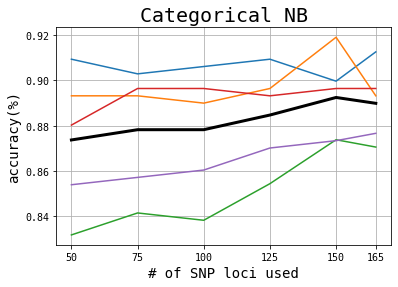

In [55]:
plt.figure(figsize=(6, 4))
for i in range(n_splits):
    plt.plot(n_SNPs, work_log_[f'CatNB_scores_{i}'], color=f'C{i}')
plt.plot(n_SNPs, np.mean([work_log_[f'CatNB_scores_{i}'] for i in range(n_splits)], axis=0), color='#000000', linewidth=3)
plt.xlim(auto=False); plt.ylim(auto=False)
plt.title('Categorical NB', fontsize=20)
plt.xlabel('# of SNP loci used', fontsize=14); plt.xticks(n_SNPs, labels=n_SNPs)
plt.ylabel('accuracy(%)', fontsize=14)
plt.grid(); plt.show(); plt.close()

In [ ]:
from sklearn_genetic import GAFeatureSelectionCV
from sklearn.naive_bayes import CategoricalNB, MultinomialNB

# min_categories = np.max(Xcat, axis=0).astype(int)+1
ga_cv = GAFeatureSelectionCV(
    CategoricalNB(
        alpha=1.
    ), 
    cv=5,
)

ga_cv.fit(Xcat, y)
ga_cv.best_features_

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': 568,
    'criterion': 'entropy',
    'max_depth': 14,
    'min_samples_split': 0.003294411356704213,
    'min_samples_leaf': 0.0010234416524205442,
}

for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(df_coded, y, y, n_splits=n_splits, random_state=42)):
    pi = np.stack([
        permutation_importance(
            make_pipeline(
                DFTransformer('oh'),
                RandomForestClassifier(
                    **rf_params,
                    random_state=42
                )
            ).fit(X_tr, y_tr), 
            X_val, y_val,
            scoring='accuracy', n_repeats=30, random_state=42
        )['importances']
        for X_tr, X_val, y_tr, y_val, _, _ in cv_splitter(X_train, y_train, y_train, n_splits=n_splits-1, random_state=42)
    ], axis=-1)
    pi_mean = np.mean(pi, axis=(-1, -2))

    scores = []
    for j in range(len(n_SNPs)):
        mask_important = pi_mean >= np.sort(pi_mean)[-n_SNPs[j]]
        model = make_pipeline(
            DFTransformer('oh', mask_important),
            RandomForestClassifier(
                **rf_params,
                random_state=42
            )
        )
        model.fit(X_train.loc[:, mask_important], y_train)
        scores.append(
            accuracy_score(y_test, model.predict(X_test.loc[:, mask_important]))
        )
    scores = np.array(scores)

    work_log_[f'RF_pi_{i}'] = pi
    work_log_[f'RF_scores_{i}'] = scores

In [6]:
from catboost import CatBoostClassifier, EFstrType, Pool

catboost_params = {
    'iterations': 1690,
    'learning_rate': 0.07455163375490914,
    'depth': 5,
    'l2_leaf_reg': 0.2593960559993001
}

models_catboost = []
fi_catboost_loss = []
fi_catboost_val = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(df[genes].values.astype('<U2'), y, df['popl'], n_splits=5, random_state=42):
    model = CatBoostClassifier(random_state=42)
    model.fit(
        Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes),
        verbose=0
    )
    models_catboost.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train).ravel() == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test).ravel() == y_test)), sep=''
    )
    fi_catboost_loss.append(
        model.get_feature_importance(
            Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes), 
            type=EFstrType.LossFunctionChange
        )
    )
    fi_catboost_val.append(
        model.get_feature_importance(
            Pool(X_train, y_train, cat_features=genes, embedding_features=[], feature_names=genes), 
            type=EFstrType.PredictionValuesChange
        )
    )

train	test
97.81%	87.38%
97.98%	86.73%
97.81%	89.00%
98.14%	89.64%
97.82%	89.61%


## LR, SVM, KNN, MultinomialNB

In [59]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer
from sklearn.metrics.pairwise import distance_metrics

def nan_l1_dist(X, Y, missing_values=np.nan):
    # if Y is None:
    #     Y = X
    # assert np.isnan(missing_values)

    diff = X - Y
    na_count = np.sum(np.isnan(diff))
    distance = np.nansum(np.abs(diff))
    distance *= (X.shape[-1] / (X.shape[-1]-na_count))
    return distance

    # X_fill = np.nan_to_num(X)
    # Y_fill = np.nan_to_num(Y)
    # distances = distance_metrics()['manhattan'](X_fill, Y_fill)
    # distances -= np.dot(np.abs(X_fill), np.isnan(Y).T)
    # distances -= np.dot(np.isnan(X), np.abs(Y_fill).T)
    
    # notna_count = np.dot(~np.isnan(X), ~np.isnan(Y).T)
    # distances[notna_count == 0] = np.nan
    # distances /= np.maximum(1, notna_count)
    # distances *= X.shape[-1]

    # return distances    

In [84]:
from sklearn.linear_model import LogisticRegression

lr_params = {
    'knnimputer__n_neighbors': 45,
    # 'knnimputer__metric': nan_l1_dist,
    'logisticregression__penalty': 'elasticnet',
    'logisticregression__C': 0.029598512368422047,
    'logisticregression__l1_ratio': 0.23215770943111214
}
for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(df_coded, y, y, n_splits=n_splits, random_state=42)):
    pi = np.stack([
        permutation_importance(
            make_pipeline(
                DFTransformer('num'),
                KNNImputer(),
                LogisticRegression(
                    solver='saga',
                    random_state=42
                )
            ).set_params(**lr_params).fit(X_tr, y_tr), 
            X_val, y_val,
            scoring='accuracy', n_repeats=30, random_state=42
        )['importances']
        for X_tr, X_val, y_tr, y_val, _, _ in cv_splitter(X_train, y_train, y_train, n_splits=n_splits-1, random_state=42)
    ], axis=-1)
    pi_mean = np.mean(pi, axis=(-1, -2))

    scores = []
    for j in range(len(n_SNPs)):
        mask_important = pi_mean >= np.sort(pi_mean)[-n_SNPs[j]]
        model = make_pipeline(
            DFTransformer('num', mask_important),
            KNNImputer(),
            LogisticRegression(
                solver='saga',
                random_state=42
            )
        ).set_params(**lr_params)
        model.fit(X_train.loc[:, mask_important], y_train)
        scores.append(
            accuracy_score(y_test, model.predict(X_test.loc[:, mask_important]))
        )
    scores = np.array(scores)

    work_log_[f'LR_pi_{i}'] = pi
    work_log_[f'LR_scores_{i}'] = scores

In [71]:
from sklearn.svm import SVC

svc_params = {
    'knnimputer__n_neighbors': 12,
    'knnimputer__metric': 'nan_euclidean',
    'svc__C': 0.3289812567312727,
    'svc__kernel': 'poly',
    'svc__degree': 8,
    'svc__gamma': 'auto'
}

for i, (X_train, X_test, y_train, y_test, _, _) in enumerate(cv_splitter(df_coded, y, y, n_splits=n_splits, random_state=42)):
    pi = np.stack([
        permutation_importance(
            make_pipeline(
                DFTransformer('num'),
                KNNImputer(),
                SVC(random_state=42)
            ).set_params(**svc_params).fit(X_tr, y_tr), 
            X_val, y_val,
            scoring='accuracy', n_repeats=30, random_state=42
        )['importances']
        for X_tr, X_val, y_tr, y_val, _, _ in cv_splitter(X_train, y_train, y_train, n_splits=n_splits-1, random_state=42)
    ], axis=-1)
    pi_mean = np.mean(pi, axis=(-1, -2))

    scores = []
    for j in range(len(n_SNPs)):
        mask_important = pi_mean >= np.sort(pi_mean)[-n_SNPs[j]]
        model = make_pipeline(
            DFTransformer('num', mask_important),
            KNNImputer(),
            SVC(random_state=42)
        ).set_params(**svc_params)
        model.fit(X_train.loc[:, mask_important], y_train)
        scores.append(
            accuracy_score(y_test, model.predict(X_test.loc[:, mask_important]))
        )
    scores = np.array(scores)

    work_log_[f'SVC_pi_{i}'] = pi
    work_log_[f'SVC_scores_{i}'] = scores

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn_params= {
    'knnimputer__n_neighbors': 6,
    'knnimputer__metric': 'nan_euclidean',
    'kneighborsclassifier__n_neighbors': 15,
    'kneighborsclassifier__weights': 'distance',
    'kneighborsclassifier__metric': 'euclidean'
}
models_knn = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        KNeighborsClassifier(
            n_neighbors=25, 
            weights='uniform',
            metric='manhattan'
        )
    )
    model.set_params(**knn_params)
    model.fit(X_train, y_train)
    models_knn.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
100.00%	82.20%
100.00%	84.79%
100.00%	82.52%
100.00%	81.88%
100.00%	84.74%


In [11]:
from sklearn.naive_bayes import MultinomialNB

models_mn_nb = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        MultinomialNB(
            alpha=1.
        )
    )
    model.fit(X_train, y_train)
    models_mn_nb.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
90.93%	86.41%
90.69%	88.03%
90.69%	89.64%
89.31%	92.23%
90.21%	90.26%


## What about DNN?

In [12]:
from sklearn.neural_network import MLPClassifier

models_mlp = []
print('train\ttest')
for X_train, X_test, y_train, y_test in cv_splitter(Xnum, y, df['popl'], n_splits=5, random_state=42):
    model = make_pipeline(
        KNNImputer(
            n_neighbors=5, 
            metric=nan_l1_dist
        ),
        MLPClassifier(
            hidden_layer_sizes=(128, 32, ),
            alpha=1e-2,
            max_iter=2000,
        )
    )
    model.fit(X_train, y_train)
    models_mlp.append(model)
    print(
        '%.2f%%' % (100*np.mean(model.predict(X_train) == y_train)), '\t',
        '%.2f%%' % (100*np.mean(model.predict(X_test) == y_test)), sep=''
    )

train	test
99.92%	88.35%
99.92%	86.41%
100.00%	88.67%
100.00%	91.59%
99.92%	87.34%


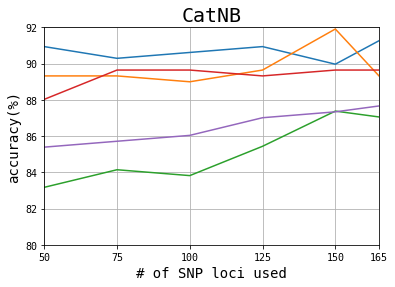

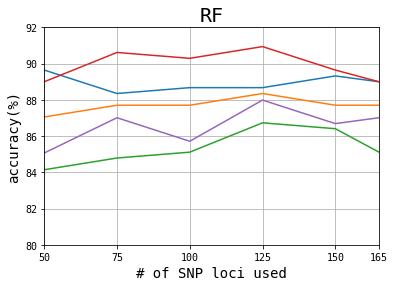

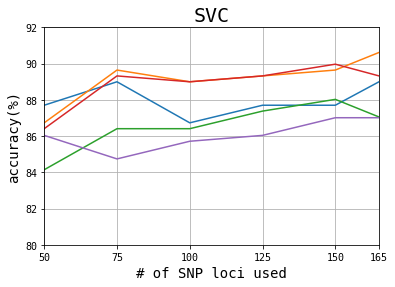

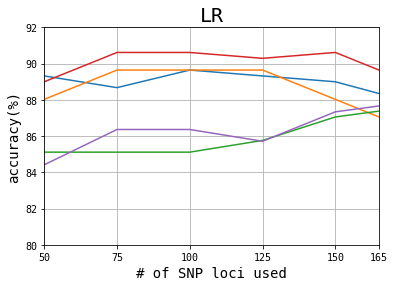

In [85]:
for name in ['CatNB', 'RF', 'SVC', 'LR']:
    plt.figure(figsize=(6, 4))
    for i in range(5):
        scores = 100*work_log_[f'{name}_scores_{i}']
        plt.plot(n_SNPs, scores, color=f'C{i}')
    plt.title(f'{name}', fontsize=20)
    plt.xlim(min(n_SNPs), max(n_SNPs)); plt.xticks(n_SNPs); plt.xlabel('# of SNP loci used', fontsize=14)
    plt.ylim(80, 92); plt.ylabel('accuracy(%)', fontsize=14)
    plt.grid(); plt.show(); plt.close()

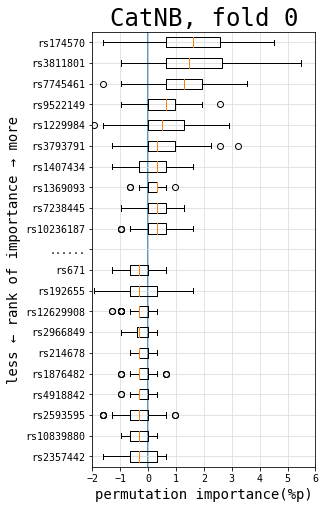

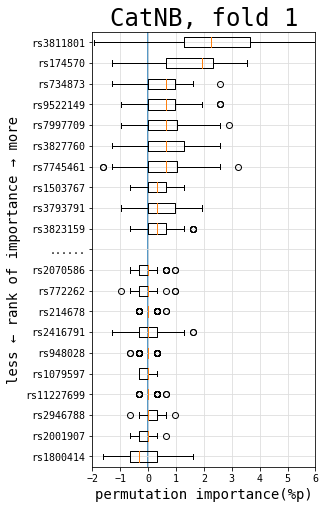

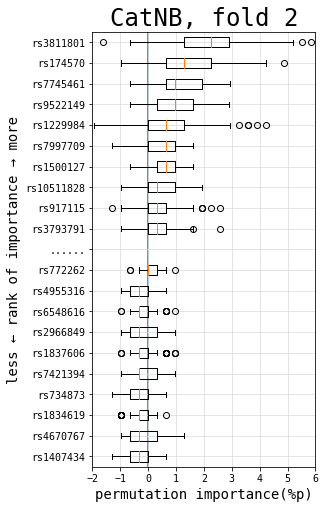

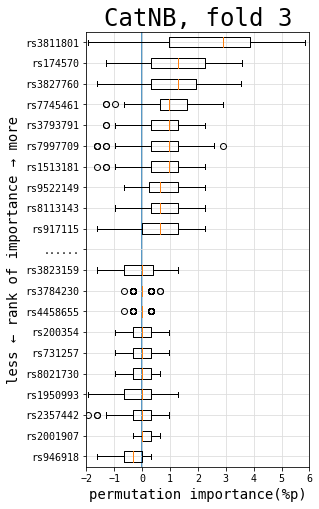

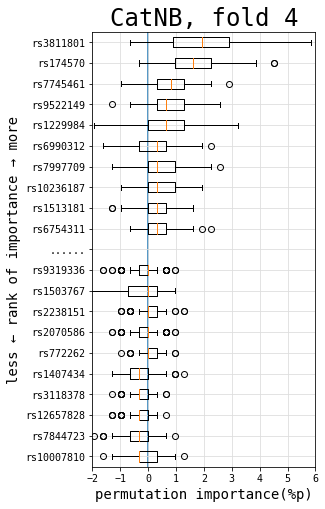

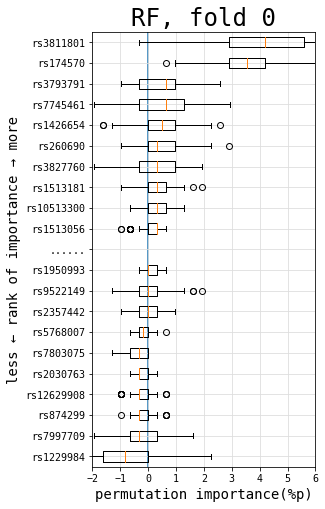

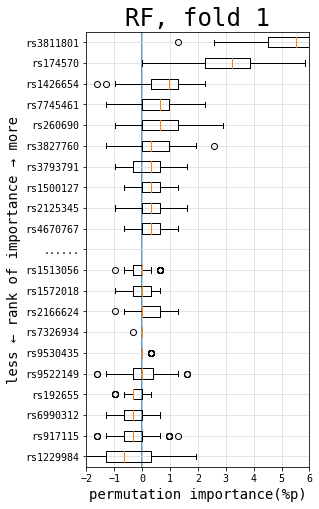

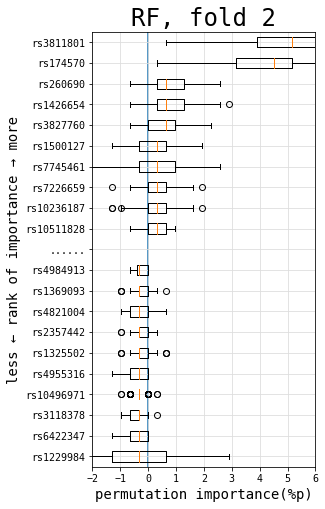

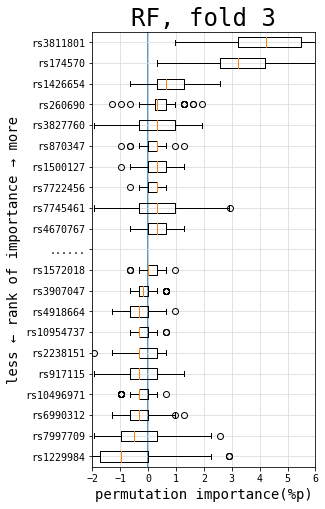

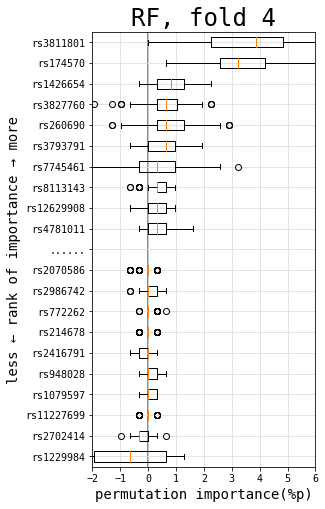

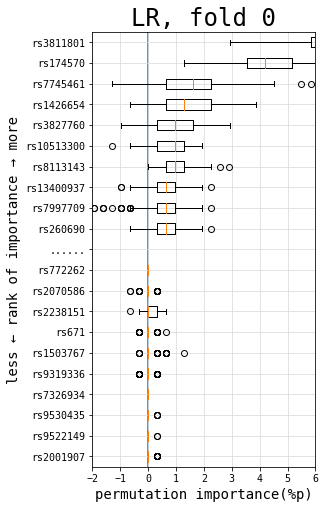

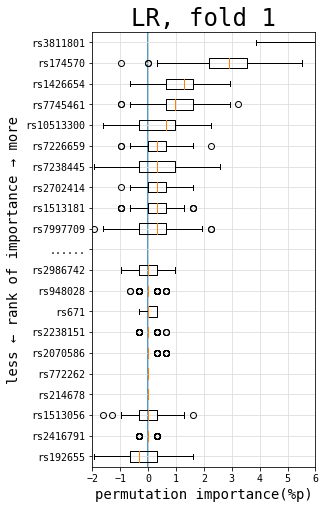

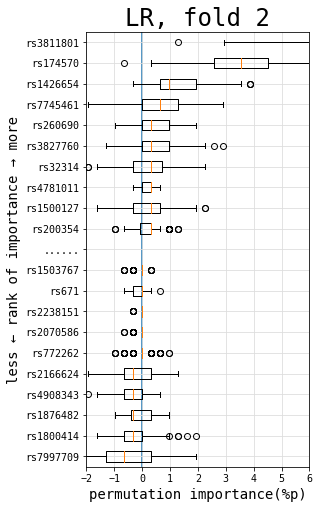

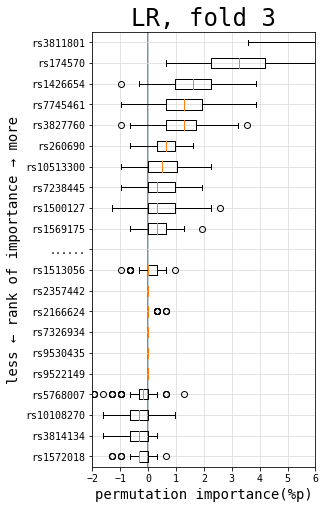

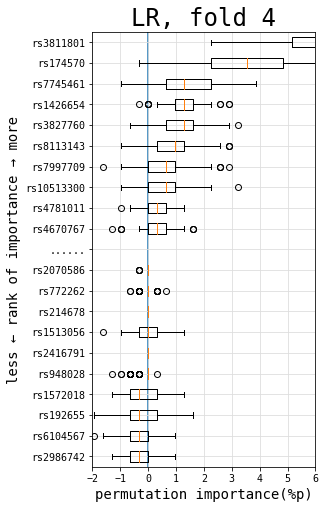

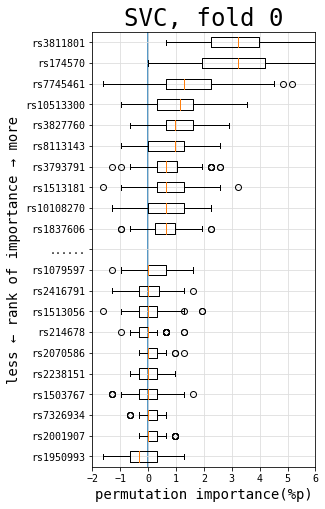

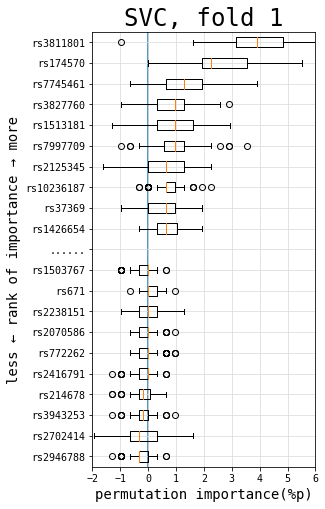

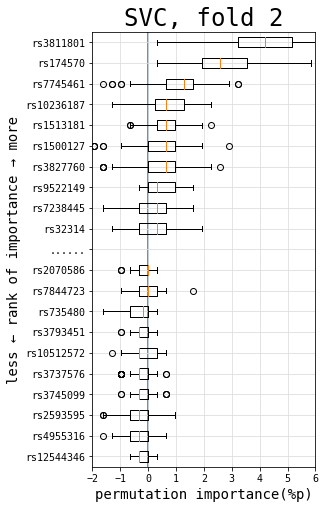

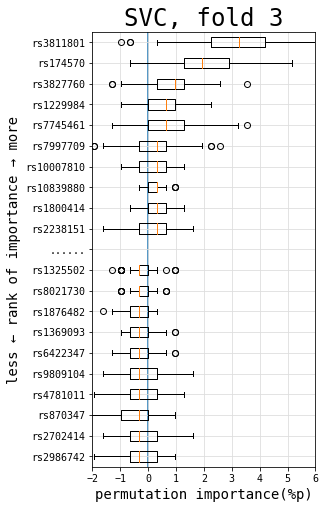

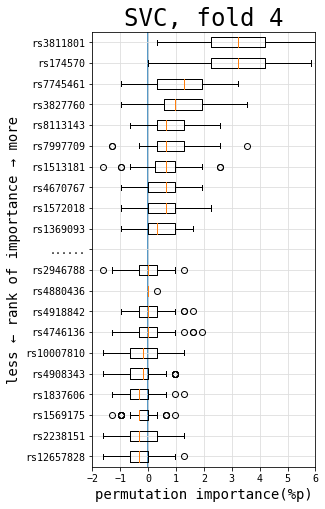

In [150]:
import itertools

model_name = 'CatNB'
fold_num = 0
top_k = 10
bottom_k = 10

for model_name, fold_num in itertools.product(['CatNB', 'RF', 'LR', 'SVC'], range(5)):
    
    plt.figure(figsize=(4, 8))

    pi = 100*work_log_[f'{model_name}_pi_{fold_num}'].reshape(df_coded.shape[1], -1)
    args = np.argsort(np.median(pi, axis=-1))
    plt.boxplot(pi[args[:top_k]].T, vert=False, positions=np.arange(1, top_k+1))
    plt.boxplot(pi[args[-bottom_k:]].T, vert=False, positions=np.arange(top_k+2, top_k+bottom_k+2))
    plt.gca().axvline(x=0, ymin=0, ymax=1, zorder=-1)

    snp_names = np.array(genes)[args]

    plt.title(f'{model_name}, fold {fold_num}', fontsize=24)
    plt.ylabel('less ← rank of importance → more', fontsize=14)
    plt.yticks(
        np.arange(1, top_k+bottom_k+2),
        labels=np.concatenate([snp_names[:top_k], ['......'], snp_names[-bottom_k:]]), 
        # ha='left'
    )
    plt.xticks(np.arange(-2, 6+1)); plt.xlim(-2, 6)
    plt.xlabel('permutation importance(%p)', fontsize=14)
    plt.grid(color='#dddddd', zorder=-2)
    plt.show(); plt.close()

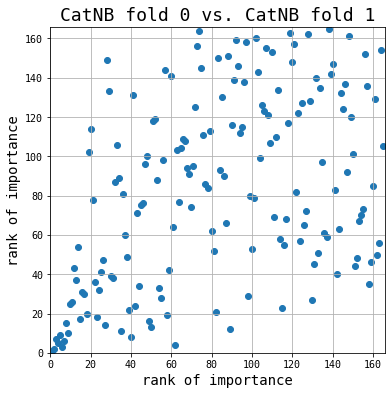

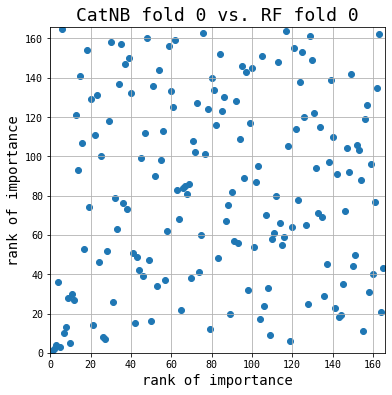

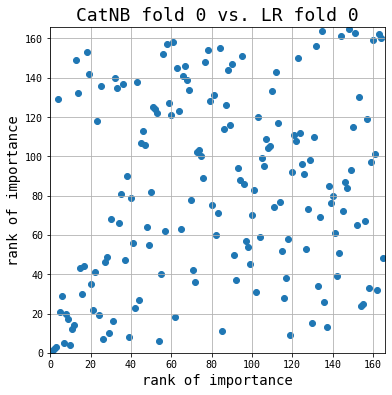

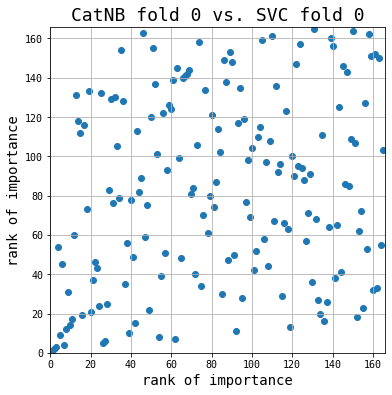

In [166]:
# import itertools

model_name = 'CatNB'
fold_num = 1
top_k = 10
bottom_k = 10

for model_name in ['CatNB', 'RF', 'LR', 'SVC']:
    mod_1 = 'CatNB fold 0'
    if model_name == 'RF':
        fold_num = 0
    mod_2 = f'{model_name} fold {fold_num}'
    
    plt.figure(figsize=(6, 6))

    pi_1 = 100*work_log_['CatNB_pi_0'].reshape(df_coded.shape[1], -1)
    pi_2 = 100*work_log_[f'{model_name}_pi_{fold_num}'].reshape(df_coded.shape[1], -1)
    pi_1 = np.argsort(np.argsort(-np.mean(pi_1, axis=-1))) +1
    pi_2 = np.argsort(np.argsort(-np.mean(pi_2, axis=-1))) +1

    plt.scatter(pi_1, pi_2)

    plt.title(f'{mod_1} vs. {mod_2}', fontsize=18)
    plt.xlim(0, 166); plt.ylim(0, 166)
    plt.ylabel('rank of importance', fontsize=14)
    plt.xlabel('rank of importance', fontsize=14)
    plt.grid()
    plt.show(); plt.close()